# Load data & check

In [22]:
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

csv_path = Path(r"D:\github\AIO2026\3_Project1\student_performance_interactions.csv")
# If the notebook is in a different folder, adjust the path accordingly.
df = pd.read_csv(csv_path)

df.head()

,student_id,final_score,grade,pass_fail,previous_score,math_prev_score,science_prev_score,language_prev_score,daily_study_hours,attendance_percentage,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation_score,exam_anxiety_score,parent_education_level,study_environment
0,S0001,60.137241,D,1,60.599707,61.488212,53.568119,64.972292,1.427203,75.738405,68.534371,6.809352,3.313096,65.059425,4.150025,6.104103,Master,Noisy
1,S0002,99.021977,A,1,92.289287,85.612565,91.873759,89.040461,4.813612,89.602736,91.990197,5.567793,4.925359,76.016617,8.714693,1.982358,High School,Quiet
2,S0003,70.522955,C,1,80.259667,82.160656,72.736065,74.243663,1.240908,81.495426,69.669666,6.702875,5.107888,113.616872,5.928220,4.463662,High School,Moderate
3,S0004,63.448537,D,1,72.926217,75.979145,76.726496,67.715995,2.190601,71.472047,71.976757,7.854439,3.772446,108.686690,4.224928,4.740474,High School,Noisy
4,S0005,66.483019,C,1,48.581025,51.379977,48.993224,46.145011,2.192265,64.276582,68.940591,7.662429,1.898989,42.107294,9.506815,1.143852,Master,Quiet


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 1000 non-null   object 
 1   final_score                1000 non-null   float64
 2   grade                      1000 non-null   object 
 3   pass_fail                  1000 non-null   int64  
 4   previous_score             1000 non-null   float64
 5   math_prev_score            1000 non-null   float64
 6   science_prev_score         1000 non-null   float64
 7   language_prev_score        1000 non-null   float64
 8   daily_study_hours          1000 non-null   float64
 9   attendance_percentage      1000 non-null   float64
 10  homework_completion_rate   1000 non-null   float64
 11  sleep_hours                1000 non-null   float64
 12  screen_time_hours          1000 non-null   float64
 13  physical_activity_minutes  1000 non-null   float6

# Simple Linear Regression
## Choosing Dependent Variable 

In [24]:
target = 'final_score'
# columns 4..15 (1-based indexing) -> indices 3..14 (0-based)
cols_to_check = list(df.columns[3:15])

corrs = {}
for col in cols_to_check:
    series = pd.to_numeric(df[col], errors='coerce')
    corr = df[target].corr(series)
    corrs[col] = corr

corr_df = pd.DataFrame.from_dict(corrs, orient='index', columns=['pearson_corr'])
corr_df = corr_df.sort_values('pearson_corr', key=lambda x: x.abs(), ascending=False)

print('Columns checked (4..15):', cols_to_check)
print('\nPearson correlations with `final_score` (sorted by absolute value):')
print(corr_df)

# Keep the results in a variable for later use
correlation_results = corr_df

Columns checked (4..15): ['pass_fail', 'previous_score', 'math_prev_score', 'science_prev_score', 'language_prev_score', 'daily_study_hours', 'attendance_percentage', 'homework_completion_rate', 'sleep_hours', 'screen_time_hours', 'physical_activity_minutes', 'motivation_score']

Pearson correlations with `final_score` (sorted by absolute value):
                           pearson_corr
previous_score                 0.843755
math_prev_score                0.825755
science_prev_score             0.823998
language_prev_score            0.810688
attendance_percentage          0.737720
pass_fail                      0.484865
daily_study_hours              0.357275
homework_completion_rate       0.339800
motivation_score               0.255734
physical_activity_minutes     -0.044330
sleep_hours                    0.032623
screen_time_hours             -0.029856


Coefficient: 0.7495
Intercept: 20.6812
R^2 (test): 0.7590
MSE (test): 48.4527


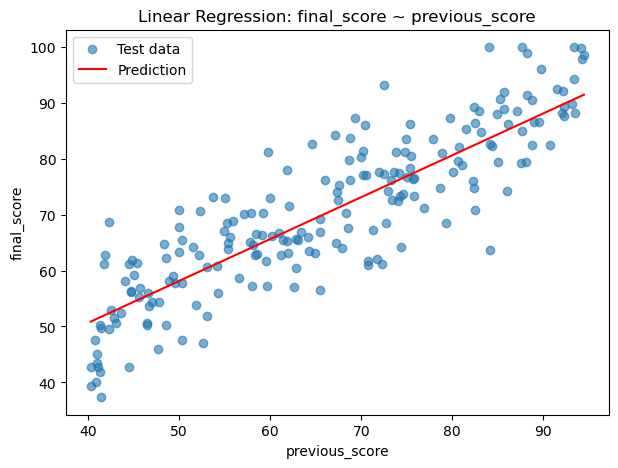

In [30]:
X = pd.to_numeric(df['previous_score'], errors='coerce').values.reshape(-1, 1)
y = pd.to_numeric(df['final_score'], errors='coerce').values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Coefficient: {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R^2 (test): {r2:.4f}")
print(f"MSE (test): {mse:.4f}")

# Plot test points and regression line
plt.figure(figsize=(7,5))
plt.scatter(X_test, y_test, alpha=0.6, label='Test data')
# sort for plotting line
idx = np.argsort(X_test.ravel())
plt.plot(X_test.ravel()[idx], y_pred[idx], color='red', label='Prediction')
plt.xlabel('previous_score')
plt.ylabel('final_score')
plt.title('Linear Regression: final_score ~ previous_score')
plt.legend()
plt.show()

In [33]:
print(X_train.shape)    
print(X_test.shape)
print(X_train_flat.shape)

(800, 1)
(200, 1)
(800,)


## Gradient Decent

Epoch 100/1000, Cost: 85.3417
Epoch 200/1000, Cost: 85.2918
Epoch 300/1000, Cost: 85.2419
Epoch 400/1000, Cost: 85.1922
Epoch 500/1000, Cost: 85.1425
Epoch 600/1000, Cost: 85.0930
Epoch 700/1000, Cost: 85.0435
Epoch 800/1000, Cost: 84.9942
Epoch 900/1000, Cost: 84.9450
Epoch 1000/1000, Cost: 84.8959

Gradient Descent Results:
w1 (Coefficient): 1.0370
w0 (Intercept): 0.2373
R^2 (test): 0.6603
MSE (test): 68.2935


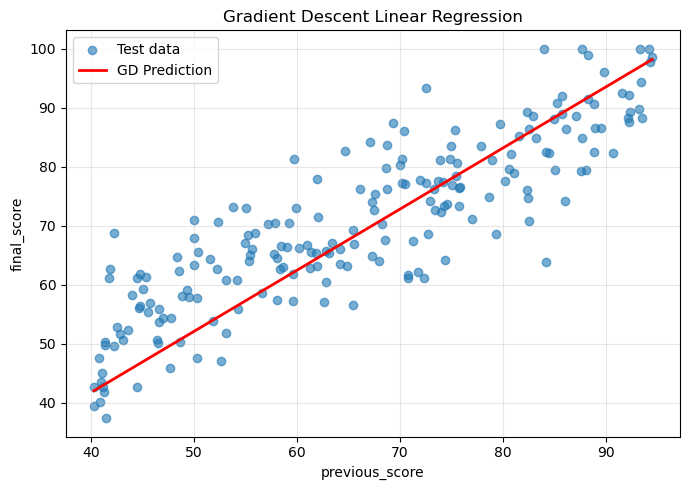

In [26]:
# Gradient Descent implementation from scratch
# Flatten X_train since it's 2D (n, 1)
X_train_flat = X_train.ravel()
X_test_flat = X_test.ravel()

# Initialize parameters
w1 = 0.0
w0 = 0.0
alpha = 0.0001  # Learning rate (smaller for stability)
epochs = 1000

# Store cost history for visualization
cost_history = []

# Gradient Descent Loop
for epoch in range(epochs):
    # Make predictions
    y_pred = w1 * X_train_flat + w0
    
    # Calculate errors
    error = y_train - y_pred
    
    # Calculate gradients
    dw1 = (-2) * np.average(X_train_flat * error)
    dw0 = (-2) * np.average(error)
    
    # Update weights
    w1 = w1 - alpha * dw1
    w0 = w0 - alpha * dw0
    
    # Calculate cost (MSE)
    cost = np.mean((y_train - y_pred) ** 2)
    cost_history.append(cost)
    
    # Print progress every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Cost: {cost:.4f}")

print(f"\nGradient Descent Results:")
print(f"w1 (Coefficient): {w1:.4f}")
print(f"w0 (Intercept): {w0:.4f}")

# Evaluate on test set
y_pred_test = w1 * X_test_flat + w0
mse_test = np.mean((y_test - y_pred_test) ** 2)
r2_test = 1 - (np.sum((y_test - y_pred_test) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

print(f"R^2 (test): {r2_test:.4f}")
print(f"MSE (test): {mse_test:.4f}")

# Regression line
plt.figure(figsize=(7,5))
plt.scatter(X_test_flat, y_test, alpha=0.6, label='Test data')
idx = np.argsort(X_test_flat)
plt.plot(X_test_flat[idx], y_pred_test[idx], color='red', linewidth=2, label='GD Prediction')
plt.xlabel('previous_score')
plt.ylabel('final_score')
plt.title('Gradient Descent Linear Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [27]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(800, 1)
(800,)
(200, 1)
(200,)


In [28]:
X_train.head(5)

AttributeError: 'numpy.ndarray' object has no attribute 'head'